# Machine Learning Technologies — In-Class Lab Assessment
## Group A — Dry Bean Dataset

**Student Name:**  ARIEL CASSIANO NUNES
**Student ID:**  G00418763

> Replace your random seed with your student ID number (remove leading G and zeros).
> Feel free to add extra code blocks as needed

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report)

In [2]:
SEED = 418763
df = pd.read_csv("drybean.csv")

---
## Task 1 — Exploratory Data Analysis

In [3]:
# 1.1 Display shape and first rows
print(df.shape)
df.head()

(13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

In [5]:
# 1.2 Check for missing values
print('NaN per column:\n', df.isnull().sum())

NaN per column:
 Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64


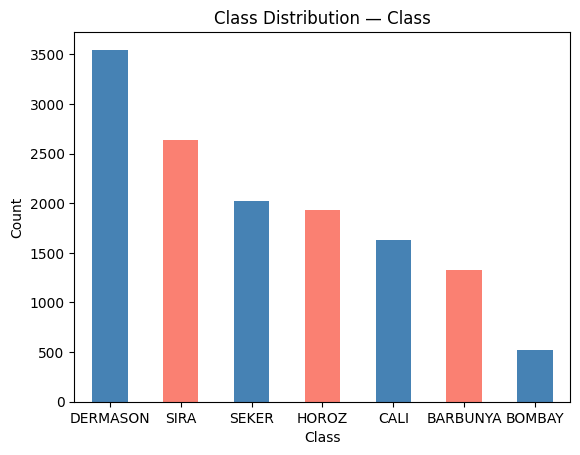

In [6]:
# 1.3 Class distribution plot
df["Class"].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.title(f'Class Distribution — {df["Class"].name}')
plt.show()


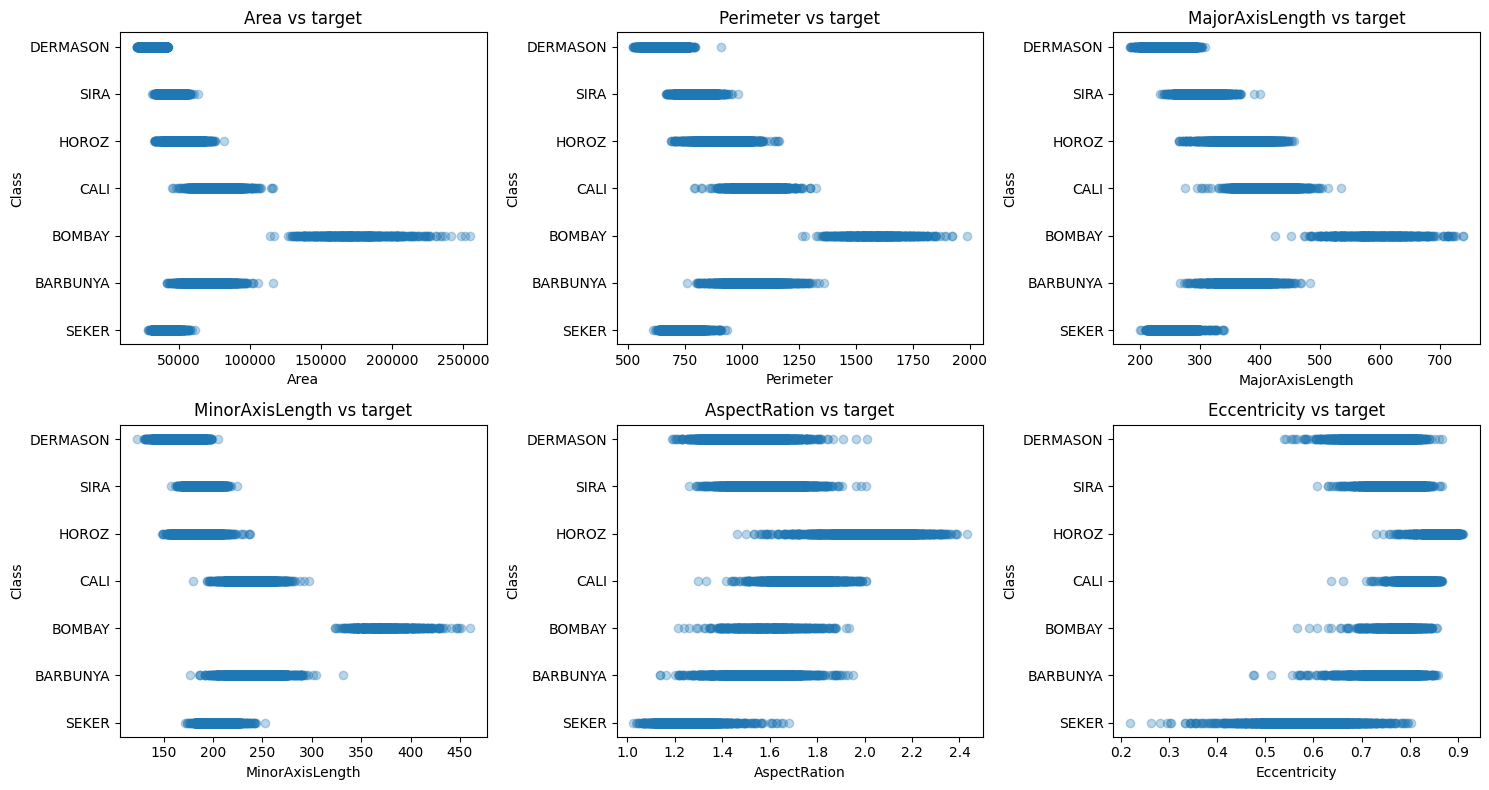

In [7]:
# 1.4 Feature distributions / boxplots

# Choose any two features and produce a scatter plot with points coloured by class
features = df.columns[:-1]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, feat in zip(axes.flatten(), features):
    ax.scatter(df[feat], df['Class'], alpha=0.3)
    ax.set_xlabel(feat)
    ax.set_ylabel('Class')
    ax.set_title(f'{feat} vs target')

plt.tight_layout()
plt.show()

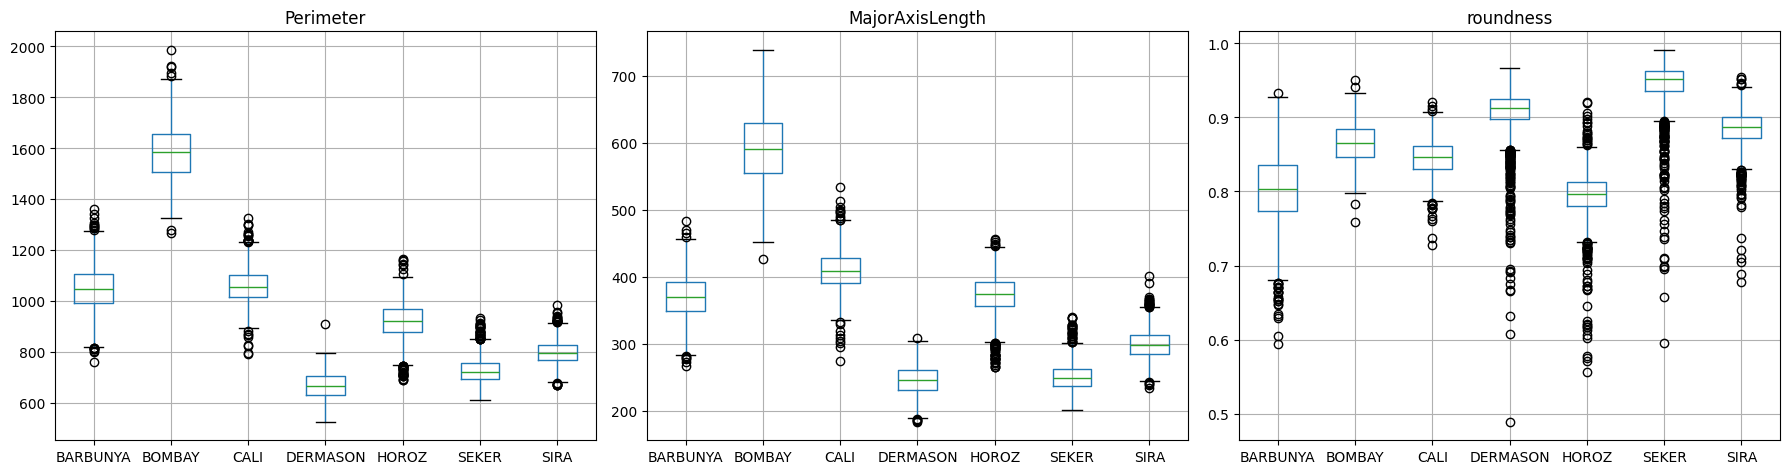

In [8]:
# Boxplots for at least three further fetures features grouped by class
features = ["Perimeter", "MajorAxisLength", "roundness"]

fig, axes = plt.subplots(1, len(features), figsize=(6 * len(features), 5))
for ax, feat in zip(axes, features):
    df.boxplot(column=feat, by="Class", ax=ax)
    ax.set_title(feat)
    ax.set_xlabel("")
plt.suptitle('')
plt.tight_layout()
plt.show()

**1.5 EDA Summary** *(3–5 sentences — what does the EDA tell you about data quality, class balance, and notable features?)*

- The data is unbalanced with DERMASON and SIRA being more present that all others.
- Minor axis length, perimter, area, and major axis length seem to contribute more towards the classification.
- Feature scalling is needed since the numeric values range from large to quite small values. Higher numeric values could end up making our prediction inaccurate.

---
## Task 2 — Data Preparation

In [9]:
# Preprocessing — handle missing values, scale features as needed
X = df.drop(columns="Class")
y = df["Class"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Means (≈0):', X_scaled.mean(axis=0).round(2))
print('Stds  (≈1):', X_scaled.std(axis=0).round(2))

Means (≈0): [ 0. -0.  0.  0. -0. -0.  0.  0.  0.  0.  0. -0.  0. -0.  0.  0.]
Stds  (≈1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [10]:
# Train / Validation / Test split (60/20/20, stratified, use SEED)
# 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=SEED
)

# Split remaining 80%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=SEED
)

---
## Task 3 — Model Training with Cross-Validation

### Model A

In [11]:
# Model A — classifier type, param grid, CV search
# Logistic Regression
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
train_accuracies = []
val_accuracies = []

for C in C_values:
    lr_model = LogisticRegression(C=C, max_iter=1000)
    lr_model.fit(X_train, y_train)
    train_accuracies.append(lr_model.score(X_train, y_train))
    val_accuracies.append(lr_model.score(X_val, y_val))

# Print results
for C, tr, va in zip(C_values, train_accuracies, val_accuracies):
    print(f"C={C:<8} Train: {tr:.4f}  Val: {va:.4f}")

best_C = C_values[np.argmax(val_accuracies)]
print(f"\nBest C: {best_C} (val accuracy: {max(val_accuracies):.4f})")

C=0.001    Train: 0.8905  Val: 0.8946
C=0.01     Train: 0.9206  Val: 0.9184
C=0.1      Train: 0.9268  Val: 0.9262
C=1        Train: 0.9276  Val: 0.9247
C=10       Train: 0.9286  Val: 0.9236
C=100      Train: 0.9291  Val: 0.9258

Best C: 0.1 (val accuracy: 0.9262)


### Model B

In [12]:
# Model B — classifier type, param grid, CV search
# K-nearest Neighbours

# Evaluate kNN (k=5) on raw, unscaled features using 5-fold cross-validation
knn_unscaled = KNeighborsClassifier(n_neighbors=5)

# 5-fold cross-validation on the training set
scores_unscaled = cross_val_score(knn_unscaled, X_train, y_train, cv=5)

print(f"CV scores (unscaled): {scores_unscaled}")
print(f"Mean: {scores_unscaled.mean():.3f} (+/- {scores_unscaled.std():.3f})")

CV scores (unscaled): [0.91738066 0.9228414  0.9228414  0.92774036 0.91610533]
Mean: 0.921 (+/- 0.004)


### Model C

In [13]:
# Model C — classifier type, param grid, CV search
# Random Forest

# Default: 100 trees, no max_depth limit, min_samples_split=2
random_forest = RandomForestClassifier(random_state=SEED)
random_forest.fit(X_train, y_train)

print("RF Validation accuracy:", random_forest.score(X_val, y_val))
print("RF Training accuracy:", random_forest.score(X_train, y_train))

# Predictions and detailed metrics on validation set
y_pred_rf = random_forest.predict(X_val)

print("\nConfusion Matrix (Random Forest):")
print(confusion_matrix(y_val, y_pred_rf))

print("\nClassification Report (Random Forest):")
print(classification_report(y_val, y_pred_rf))

RF Validation accuracy: 0.9202792064658339
RF Training accuracy: 0.999877541023757

Confusion Matrix (Random Forest):
[[246   1  13   0   0   2   2]
 [  0 105   0   0   0   0   0]
 [ 13   0 304   0   6   0   3]
 [  0   0   0 656   1  17  35]
 [  2   0   6   1 365   0  12]
 [  2   0   0   8   0 384  11]
 [  2   0   1  61   9   9 445]]

Classification Report (Random Forest):
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.93      0.93       264
      BOMBAY       0.99      1.00      1.00       105
        CALI       0.94      0.93      0.94       326
    DERMASON       0.90      0.93      0.91       709
       HOROZ       0.96      0.95      0.95       386
       SEKER       0.93      0.95      0.94       405
        SIRA       0.88      0.84      0.86       527

    accuracy                           0.92      2722
   macro avg       0.93      0.93      0.93      2722
weighted avg       0.92      0.92      0.92      2722



---
## Task 4 — Model Comparison on Validation Set

In [ ]:
models = {
    'KNN':           KNeighborsClassifier(n_neighbors=5),
    'Logistic Reg':  LogisticRegression(max_iter=1000, random_state=SEED),
    'Random Forest': RandomForestClassifier(random_state=SEED)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
         'Accuracy': accuracy_score(y_test, y_pred),

    }

results_df = pd.DataFrame(results).T
print(results_df.round(3))

               Accuracy
KNN               0.910
Logistic Reg      0.911
Random Forest     0.908


**4.3 Comparison Discussion** *(3–5 sentences — which model performs best and why?)*

- Random Forest achieves better accuracy (0.916 against 0.912 and 0.913) as it handles non-linear relationships better than the other models.

---
## Task 5 — Final Evaluation on Test Set

**5.1 Model Selection** *(2–3 sentences — which model did you choose and why?)*

YOUR ANSWER HERE

In [15]:
# Retrain chosen model on train + validation set


In [16]:
# Evaluate on test set — classification_report


In [17]:
# Confusion matrix heatmap


**5.5 Final Interpretation** *(3–5 sentences — what do the results show? Any classes the model struggles with? Is it deployment-ready?)*

YOUR ANSWER HERE